In [6]:
import pandas as pd

ev_stations = pd.read_csv(
    r"C:\Users\mariyam\Downloads\ev_charging_stations_india_cleaned.csv"
)

ev_stations.head()

,station_id,station_name,city,state,country,latitude,longitude,charging_points,status,operator
0,479727,Nikol EV Charging station,Pune,Unknown,India,18.717182,74.182921,1,Operational,Unknown
1,479445,Blaze Fast Charger For 2 Ev Wheeler,Lb Nagar,Telangana,India,17.340476,78.545395,1,Operational,Bolt.Earth (IN)
2,479438,Tata Power Charging Station,Unknown,Odisha,India,22.286961,86.790983,1,Operational,Unknown
3,479437,Hindustan Petroleum Corporation Limited Chargi...,Unknown,Odisha,India,22.449744,86.594944,2,Operational,Unknown
4,479436,Hindustan Petroleum Corporation Limited,Unknown,Odisha,India,22.449858,86.595041,1,Operational,Unknown


In [7]:
ev_stations.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   station_id       1000 non-null   int64  
 1   station_name     1000 non-null   str    
 2   city             1000 non-null   str    
 3   state            1000 non-null   str    
 4   country          1000 non-null   str    
 5   latitude         1000 non-null   float64
 6   longitude        1000 non-null   float64
 7   charging_points  1000 non-null   int64  
 8   status           1000 non-null   str    
 9   operator         1000 non-null   str    
dtypes: float64(2), int64(2), str(6)
memory usage: 78.3 KB


In [8]:
ev_stations.describe()

,station_id,latitude,longitude,charging_points
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,411186.89600,15.015117,79.487028,2.364000
std,80212.30397,5.538109,4.091311,18.963415
min,313438.00000,8.194503,72.908046,1.000000
25%,313754.75000,10.148326,76.283157,1.000000
50%,474539.50000,11.669307,76.825038,1.000000
75%,479190.25000,20.193904,83.891772,2.000000
max,479727.00000,32.214505,91.851200,600.000000


In [9]:
ev_stations["status"].value_counts()

status
Operational                   969
Not Operational                15
Temporarily Unavailable        10
Planned For Future Date         5
Partly Operational (Mixed)      1
Name: count, dtype: int64

In [10]:
ev_stations["station_id"].duplicated().sum()

np.int64(0)

In [11]:
ev_stations["charging_points"].value_counts().sort_index()

charging_points
1      577
2      278
3       58
4       35
5       12
6       30
7        5
9        1
11       3
600      1
Name: count, dtype: int64

In [12]:
print("Latitude range:", ev_stations["latitude"].min(), "to", ev_stations["latitude"].max())
print("Longitude range:", ev_stations["longitude"].min(), "to", ev_stations["longitude"].max())

Latitude range: 8.194502907 to 32.21450539
Longitude range: 72.90804617 to 91.8512


In [13]:
ev_stations["Operational_Flag"] = (
    ev_stations["status"] == "OPerational"
).astype(int)
ev_stations[["status", "Operational_Flag"]].head(10)

,status,Operational_Flag
0,Operational,0
1,Operational,0
2,Operational,0
3,Operational,0
4,Operational,0
5,Operational,0
6,Operational,0
7,Operational,0
8,Operational,0
9,Operational,0


In [14]:
ev_stations["Active_Charging_Points"] = (
    ev_stations["charging_points"] * ev_stations["Operational_Flag"]
)

ev_stations[[
    "charging_points",
    "status",
    "Operational_Flag",
    "Active_Charging_Points"
]].head(10)

,charging_points,status,Operational_Flag,Active_Charging_Points
0,1,Operational,0,0
1,1,Operational,0,0
2,1,Operational,0,0
3,2,Operational,0,0
4,1,Operational,0,0
5,1,Operational,0,0
6,1,Operational,0,0
7,3,Operational,0,0
8,1,Operational,0,0
9,1,Operational,0,0


In [15]:
total_stations = len(ev_stations)
total_charging_points = ev_stations["charging_points"].sum()
operational_stations = ev_stations["Operational_Flag"].sum()
active_charging_points = ev_stations["Active_Charging_Points"].sum()

operational_rate = operational_stations / total_stations * 100
active_point_rate = active_charging_points / total_charging_points * 100

print("Total Stations:", total_stations)
print("Total Charging Points:", total_charging_points)
print("Operational Stations:", operational_stations)
print("Operational Rate:", round(operational_rate, 2), "%")
print("Active Charging Points:", active_charging_points)
print("Active Charging Point Rate:", round(active_point_rate, 2), "%")

Total Stations: 1000
Total Charging Points: 2364
Operational Stations: 0
Operational Rate: 0.0 %
Active Charging Points: 0
Active Charging Point Rate: 0.0 %


In [16]:
ev_stations["status"].unique()

<StringArray>
[               'Operational',            'Not Operational',
    'Temporarily Unavailable', 'Partly Operational (Mixed)',
    'Planned For Future Date']
Length: 5, dtype: str

In [17]:
ev_stations["Operational_Flag"] = (
    ev_stations["status"].astype(str).str.strip().eq("Operational").astype(int)
)

print("Operational stations:", ev_stations["Operational_Flag"].sum())

Operational stations: 969


In [18]:
ev_stations["Active_Charging_Points"] = (
    ev_stations["charging_points"] * ev_stations["Operational_Flag"]
)

print("Active Charging Points:", ev_stations["Active_Charging_Points"].sum())

Active Charging Points: 2320


In [19]:
operational_rate = (
    ev_stations["Operational_Flag"].sum()
    / len(ev_stations)
) * 100

active_point_rate = (
    ev_stations["Active_Charging_Points"].sum()
    / ev_stations["charging_points"].sum()
) * 100

print("Operational Rate:", round(operational_rate, 2), "%")
print("Active Charging Point Rate:", round(active_point_rate, 2), "%")

Operational Rate: 96.9 %
Active Charging Point Rate: 98.14 %


In [20]:
mean_points = ev_stations["charging_points"].mean()
median_points = ev_stations["charging_points"].median()
std_points = ev_stations["charging_points"].std()

print("Mean Charging Points:", round(mean_points, 2))
print("Median Charging Points:", median_points)
print("Standard Deviation:", round(std_points, 2))

Mean Charging Points: 2.36
Median Charging Points: 1.0
Standard Deviation: 18.96


In [21]:
ev_stations[
    ["station_id", "station_name", "city", "state", "charging_points", "status"]
].sort_values(
    "charging_points",
    ascending=False
).head(10)

,station_id,station_name,city,state,charging_points,status
110,479330,Electric Vehicle Charging Station,Unknown,Odisha,600,Operational
294,479140,Electric Vehicle Charging Station,Unknown,Odisha,11,Operational
634,313915,Lulu International Mall EVCS - GO EC,Thiruvananthapuram,Kerala,11,Operational
210,479230,Electric Vehicle Charging Station,Unknown,Odisha,11,Operational
801,313702,Kulappully KSEB EVCS - ChargeMOD,Kulappully,Kerala,9,Operational
908,313574,Quick Charge EVCS - ChargeMOD,Karuvatta,Kerala,7,Operational
448,475660,Bundelkhand Expressway 188 Km Rest Area,Unknown,Uttar Pradesh,7,Operational
688,313861,Daffodils EVCS - GO EC,Edapally,Kerala,7,Operational
750,313754,Kanhangad KSEB EVCS - ChangeMOD,Kanhangad,Kerala,7,Operational
183,479257,Kazam Charging Station,Unknown,Odisha,7,Operational


In [22]:
Q1 = ev_stations["charging_points"].quantile(0.25)
Q3 = ev_stations["charging_points"].quantile(0.75)

IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Outlier Limit:", upper_limit)

Q1: 1.0
Q3: 2.0
IQR: 1.0
Upper Outlier Limit: 3.5


In [23]:
outliers = ev_stations[
    ev_stations["charging_points"] > upper_limit
]

print("Number of outlier stations:", len(outliers))
print("Total charging points in outlier stations:", outliers["charging_points"].sum())

Number of outlier stations: 87
Total charging points in outlier stations: 1057


In [24]:
outliers_by_state = (
    outliers.groupby("state")["charging_points"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

outliers_by_state

,count,sum
state,,
Odisha,6,638
Kerala,72,374
Uttar Pradesh,2,13
Rajasthan,2,8
Tamil Nadu,2,8
Keral,1,6
Telangana,1,6
UTTAR PRADESH,1,4


In [25]:
ev_stations[
    ev_stations["charging_points"] == ev_stations["charging_points"].max()
]

,station_id,station_name,city,state,country,latitude,longitude,charging_points,status,operator,Operational_Flag,Active_Charging_Points
110,479330,Electric Vehicle Charging Station,Unknown,Odisha,India,21.016109,81.7029,600,Operational,Unknown,1,600


In [26]:
stats_summary = ev_stations["charging_points"].agg(
    ["min", "max", "mean", "median", "std"]
)

stats_summary

min         1.000000
max       600.000000
mean        2.364000
median      1.000000
std        18.963415
Name: charging_points, dtype: float64

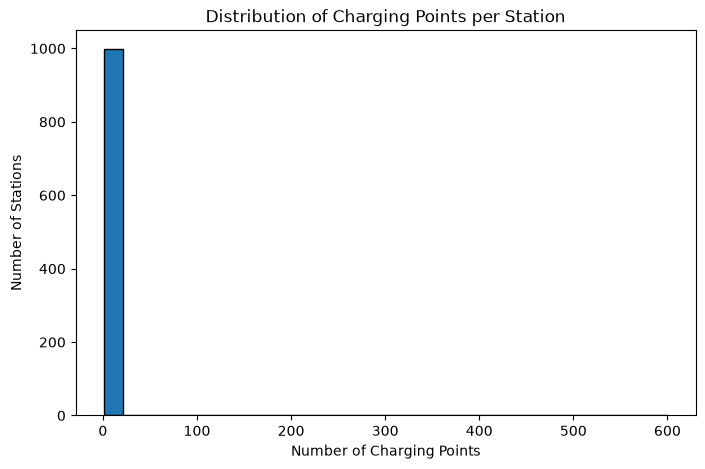

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    ev_stations["charging_points"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Charging Points per Station")
plt.xlabel("Number of Charging Points")
plt.ylabel("Number of Stations")

plt.show()

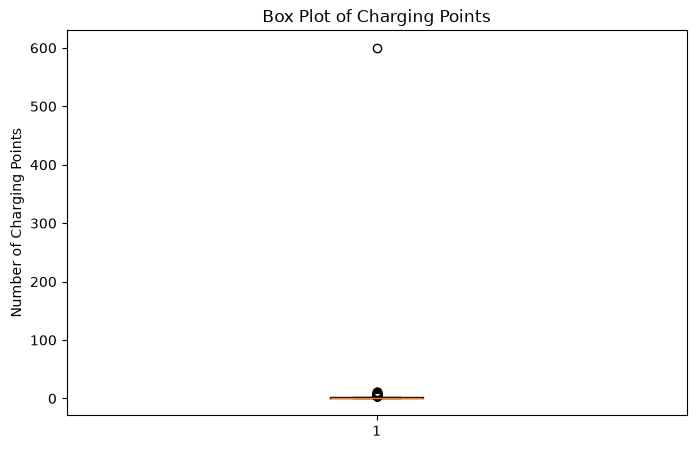

In [30]:
plt.figure(figsize=(8, 5))

plt.boxplot(
    ev_stations["charging_points"],
    orientation="vertical"
)

plt.title("Box Plot of Charging Points")
plt.ylabel("Number of Charging Points")

plt.show()

In [31]:
status_analysis = (
    ev_stations.groupby("status")["charging_points"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

status_analysis

,count,sum
status,,
Operational,969,2320
Temporarily Unavailable,10,17
Not Operational,15,16
Planned For Future Date,5,10
Partly Operational (Mixed),1,1


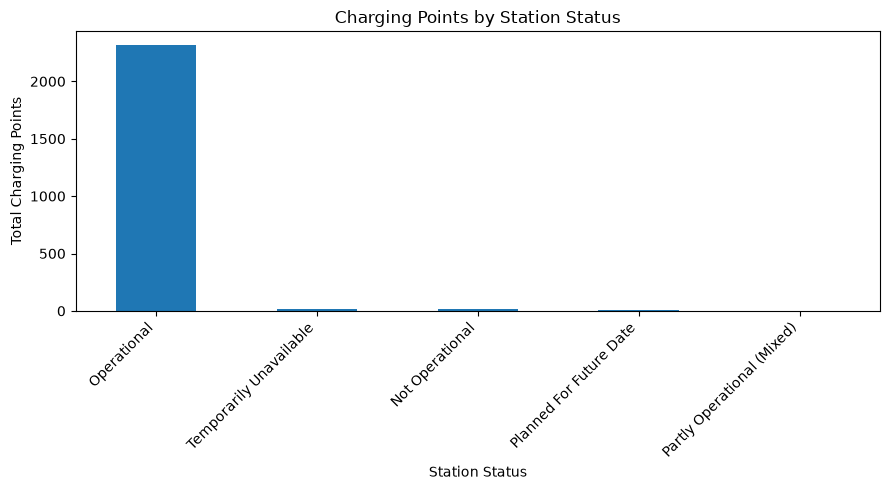

In [32]:
status_analysis["sum"].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Charging Points by Station Status")
plt.xlabel("Station Status")
plt.ylabel("Total Charging Points")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [34]:
state_mapping = {
    "GJ": "Gujarat",
    "MH": "Maharashtra",
    "MP": "Madhya Pradesh",
    "RJ": "Rajasthan",
    "Keral": "Kerala",
    "Keraka": "Kerala",
    "Lerala": "Kerala",
    "TAMILNADU": "Tamil Nadu",
    "Uttarakhnad": "Uttarakhand",
    "UTTAR PRADESH": "Uttar Pradesh"
}

ev_stations["Clean_State"] = (
    ev_stations["state"]
    .astype(str)
    .str.strip()
    .replace(state_mapping)
)

ev_stations["Clean_State"].value_counts().head(15)

Clean_State
Kerala            520
Odisha            370
Tamil Nadu         27
Uttarakhand        14
Rajasthan          11
Gujarat             9
Madhya Pradesh      9
Uttar Pradesh       8
Unknown             6
Maharashtra         6
Karnataka           6
Telangana           5
Jharkhand           2
Haryana             1
rajasthan           1
Name: count, dtype: int64

In [35]:
ev_stations["Clean_State"] = (
    ev_stations["Clean_State"]
    .astype(str)
    .str.strip()
    .str.title()
)

ev_stations["Clean_State"].value_counts().head(15)

Clean_State
Kerala            520
Odisha            370
Tamil Nadu         27
Uttarakhand        14
Rajasthan          12
Gujarat             9
Madhya Pradesh      9
Uttar Pradesh       8
Unknown             6
Maharashtra         6
Karnataka           6
Telangana           5
West Bengal         2
Jharkhand           2
Haryana             1
Name: count, dtype: int64

In [36]:
state_analysis = (
    ev_stations.groupby("Clean_State")["charging_points"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

state_analysis

,count,sum
Clean_State,,
Kerala,520,1135
Odisha,370,1041
Tamil Nadu,27,52
Uttar Pradesh,8,25
Rajasthan,12,23
Uttarakhand,14,15
Telangana,5,13
Gujarat,9,12
Madhya Pradesh,9,12


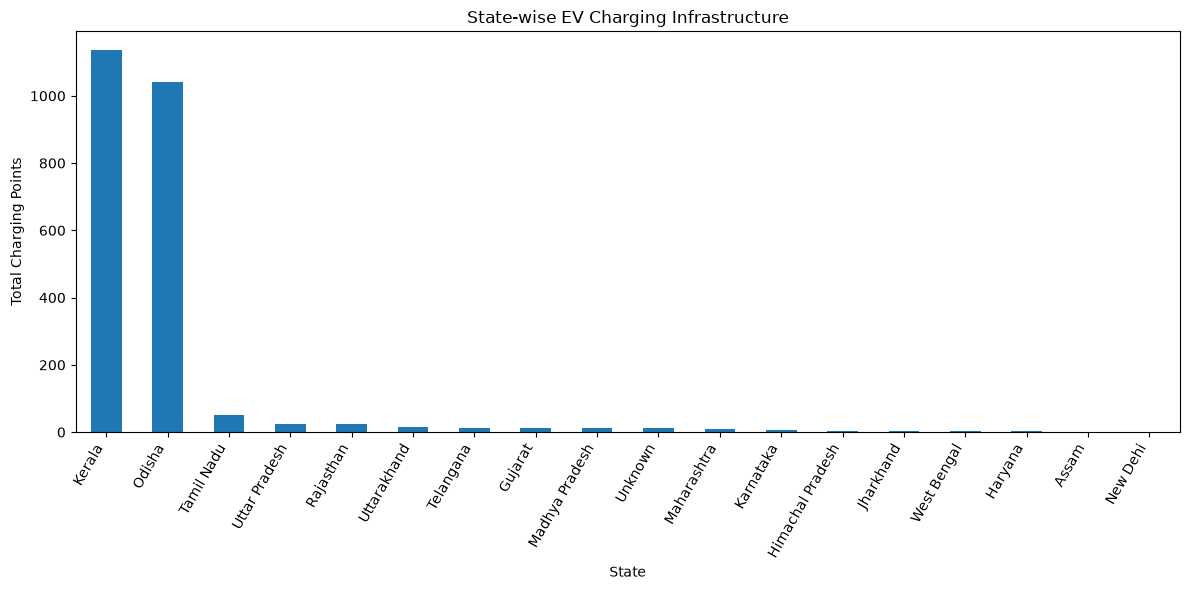

In [37]:
state_analysis["sum"].sort_values(ascending=False).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("State-wise EV Charging Infrastructure")
plt.xlabel("State")
plt.ylabel("Total Charging Points")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [38]:
ev_sales = pd.read_csv(
    r"C:\Users\mariyam\Downloads\Indian_EV_Sales_2015_2025.csv"
)

ev_sales.head()

,Year,State/UT,Vehicle_Category,Segment,Sales_Quantity,EV_Penetration (%)
0,2015,India,Two-Wheeler,High-speed e2W,15000,0.1
1,2016,India,Two-Wheeler,High-speed e2W,22000,0.2
2,2017,India,Two-Wheeler,High-speed e2W,34000,0.3
3,2018,India,Two-Wheeler,High-speed e2W,56000,0.5
4,2019,India,Two-Wheeler,High-speed e2W,152000,1.1


In [39]:
ev_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                19 non-null     int64  
 1   State/UT            19 non-null     str    
 2   Vehicle_Category    19 non-null     str    
 3   Segment             19 non-null     str    
 4   Sales_Quantity      19 non-null     int64  
 5   EV_Penetration (%)  19 non-null     float64
dtypes: float64(1), int64(2), str(3)
memory usage: 1.0 KB


In [40]:
print("Years:")
print(ev_sales["Year"].unique())

print("\nSegments:")
print(ev_sales["Segment"].unique())

Years:
[2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]

Segments:
<StringArray>
['High-speed e2W', 'Passenger 3W', 'Cargo 3W', 'Electric Cars',
 'Electric Buses']
Length: 5, dtype: str


In [41]:
ev_sales["Segment"].value_counts()

Segment
High-speed e2W    11
Passenger 3W       2
Cargo 3W           2
Electric Cars      2
Electric Buses     2
Name: count, dtype: int64

In [42]:
two_wheeler_sales = ev_sales[
    ev_sales["Segment"] == "High-speed e2W"
].sort_values("Year")

two_wheeler_sales[["Year", "Sales_Quantity", "EV_Penetration (%)"]]

,Year,Sales_Quantity,EV_Penetration (%)
0,2015,15000,0.1
1,2016,22000,0.2
2,2017,34000,0.3
3,2018,56000,0.5
4,2019,152000,1.1
5,2020,240000,1.8
6,2021,415000,2.3
7,2022,629000,3.6
8,2023,873000,5.1
9,2024,1211193,6.2


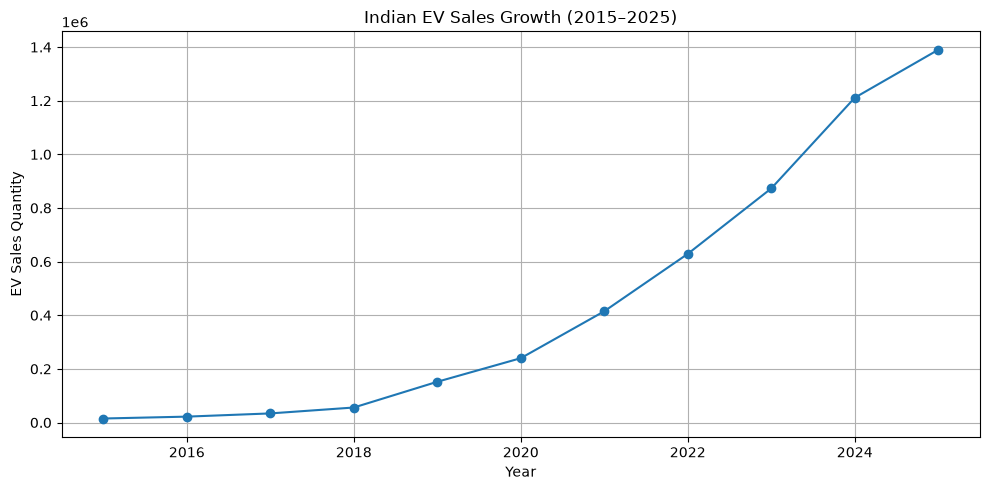

In [43]:
plt.figure(figsize=(10, 5))

plt.plot(
    two_wheeler_sales["Year"],
    two_wheeler_sales["Sales_Quantity"],
    marker="o"
)

plt.title("Indian EV Sales Growth (2015–2025)")
plt.xlabel("Year")
plt.ylabel("EV Sales Quantity")

plt.grid(True)
plt.tight_layout()
plt.show()

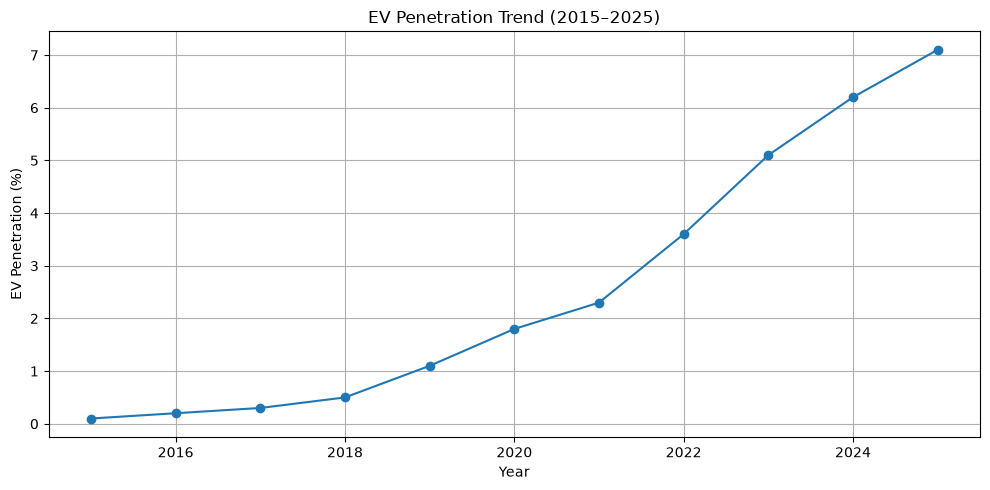

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(
    two_wheeler_sales["Year"],
    two_wheeler_sales["EV_Penetration (%)"],
    marker="o"
)

plt.title("EV Penetration Trend (2015–2025)")
plt.xlabel("Year")
plt.ylabel("EV Penetration (%)")

plt.grid(True)
plt.tight_layout()
plt.show()

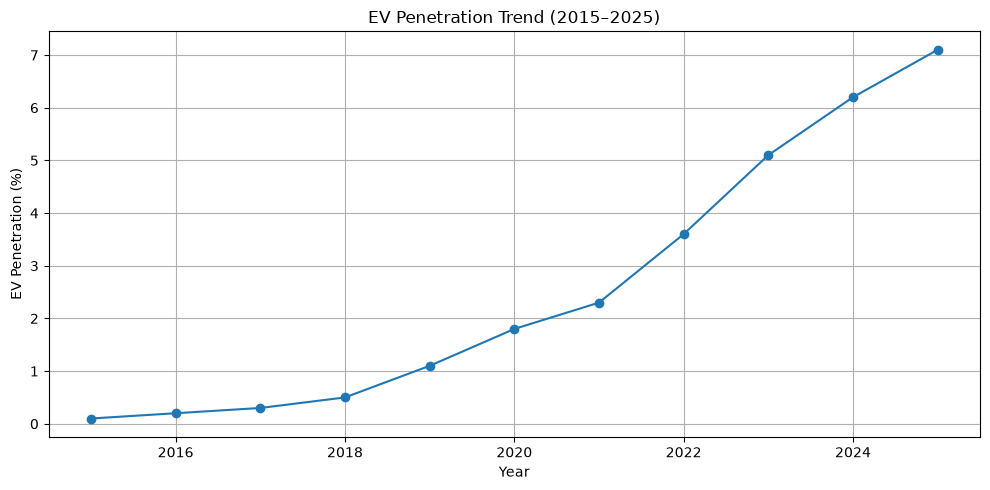

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(
    two_wheeler_sales["Year"],
    two_wheeler_sales["EV_Penetration (%)"],
    marker="o"
)

plt.title("EV Penetration Trend (2015–2025)")
plt.xlabel("Year")
plt.ylabel("EV Penetration (%)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [46]:
cities = pd.read_csv(
    r"C:\Users\mariyam\Downloads\India Cities LatLng.csv"
)

cities.head()

,city,lat,lng,country,iso2,admin_name,capital,population,population_proper
0,Delhi,28.6600,77.2300,India,IN,Delhi,admin,29617000.0,16753235.0
1,Mumbai,18.9667,72.8333,India,IN,Mahārāshtra,admin,23355000.0,12478447.0
2,Kolkāta,22.5411,88.3378,India,IN,West Bengal,admin,17560000.0,4496694.0
3,Bangalore,12.9699,77.5980,India,IN,Karnātaka,admin,13707000.0,8443675.0
4,Chennai,13.0825,80.2750,India,IN,Tamil Nādu,admin,11324000.0,6727000.0


In [47]:
cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   city               188 non-null    str    
 1   lat                188 non-null    float64
 2   lng                188 non-null    float64
 3   country            188 non-null    str    
 4   iso2               187 non-null    str    
 5   admin_name         187 non-null    str    
 6   capital            38 non-null     str    
 7   population         185 non-null    float64
 8   population_proper  185 non-null    float64
dtypes: float64(4), str(5)
memory usage: 13.3 KB


In [48]:
top_cities = (
    cities[["city", "admin_name", "population"]]
    .dropna(subset=["population"])
    .sort_values("population", ascending=False)
    .head(10)
)

top_cities

,city,admin_name,population
0,Delhi,Delhi,29617000.0
1,Mumbai,Mahārāshtra,23355000.0
2,Kolkāta,West Bengal,17560000.0
3,Bangalore,Karnātaka,13707000.0
4,Chennai,Tamil Nādu,11324000.0
5,Hyderābād,Telangana,9746000.0
6,Pune,Mahārāshtra,7764000.0
7,Ahmadābād,Gujarāt,7410000.0
8,Sūrat,Gujarāt,5807000.0
9,Lucknow,Uttar Pradesh,3382000.0


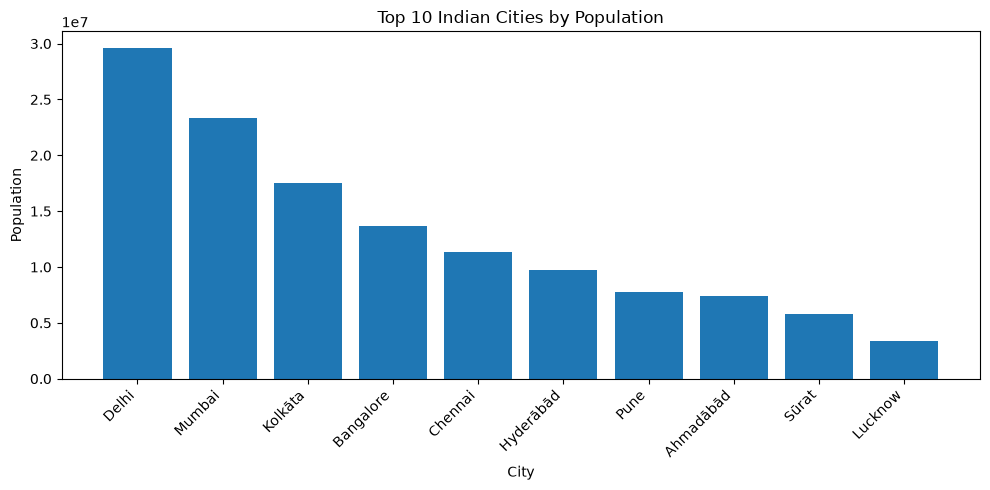

In [49]:
plt.figure(figsize=(10, 5))

plt.bar(
    top_cities["city"],
    top_cities["population"]
)

plt.title("Top 10 Indian Cities by Population")
plt.xlabel("City")
plt.ylabel("Population")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [50]:
ev_stations["Clean_City"] = (
    ev_stations["city"]
    .astype(str)
    .str.strip()
    .str.title()
)

cities["Clean_City"] = (
    cities["city"]
    .astype(str)
    .str.strip()
    .str.title()
)

print("Charging station cities:", ev_stations["Clean_City"].nunique())
print("City dataset cities:", cities["Clean_City"].nunique())

Charging station cities: 352
City dataset cities: 188


In [51]:
matched_cities = ev_stations["Clean_City"].isin(
    cities["Clean_City"]
)

print("Matched station records:", matched_cities.sum())
print("Unmatched station records:", (~matched_cities).sum())
print("Match rate:", round(matched_cities.mean() * 100, 2), "%")

Matched station records: 30
Unmatched station records: 970
Match rate: 3.0 %


In [52]:
matched_city_names = (
    ev_stations.loc[matched_cities, "Clean_City"]
    .value_counts()
)

matched_city_names

Clean_City
Thiruvananthapuram    13
Kochi                  5
Coimbatore             3
Lucknow                3
Pune                   2
Vadodara               2
Chennai                1
Salem                  1
Name: count, dtype: int64

In [53]:
state_priority = (
    ev_stations.groupby("Clean_State")
    .agg(
        Total_Stations=("station_id", "count"),
        Total_Charging_Points=("charging_points", "sum"),
        Operational_Stations=("Operational_Flag", "sum")
    )
    .reset_index()
)

state_priority["Operational_Rate"] = (
    state_priority["Operational_Stations"]
    / state_priority["Total_Stations"]
)

state_priority = state_priority.sort_values(
    "Total_Charging_Points",
    ascending=False
)

state_priority

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Stations,Operational_Rate
6,Kerala,520,1135,506,0.973077
10,Odisha,370,1041,360,0.972973
12,Tamil Nadu,27,52,27,1.000000
15,Uttar Pradesh,8,25,8,1.000000
11,Rajasthan,12,23,12,1.000000
16,Uttarakhand,14,15,9,0.642857
13,Telangana,5,13,5,1.000000
1,Gujarat,9,12,9,1.000000
7,Madhya Pradesh,9,12,9,1.000000
14,Unknown,6,11,5,0.833333


In [54]:
state_priority["Points_Per_Station"] = (
    state_priority["Total_Charging_Points"]
    / state_priority["Total_Stations"]
)

state_priority[
    [
        "Clean_State",
        "Total_Stations",
        "Total_Charging_Points",
        "Operational_Stations",
        "Operational_Rate",
        "Points_Per_Station"
    ]
].sort_values(
    "Points_Per_Station",
    ascending=False
)

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Stations,Operational_Rate,Points_Per_Station
15,Uttar Pradesh,8,25,8,1.000000,3.125000
10,Odisha,370,1041,360,0.972973,2.813514
13,Telangana,5,13,5,1.000000,2.600000
6,Kerala,520,1135,506,0.973077,2.182692
2,Haryana,1,2,1,1.000000,2.000000
3,Himachal Pradesh,1,2,1,1.000000,2.000000
12,Tamil Nadu,27,52,27,1.000000,1.925926
11,Rajasthan,12,23,12,1.000000,1.916667
14,Unknown,6,11,5,0.833333,1.833333
1,Gujarat,9,12,9,1.000000,1.333333


In [55]:
total_stations = state_priority["Total_Stations"].sum()
total_points = state_priority["Total_Charging_Points"].sum()

state_priority["Station_Share"] = (
    state_priority["Total_Stations"] / total_stations
)

state_priority["Charging_Point_Share"] = (
    state_priority["Total_Charging_Points"] / total_points
)

state_priority["Infrastructure_Gap"] = (
    state_priority["Station_Share"]
    - state_priority["Charging_Point_Share"]
)

state_priority[
    [
        "Clean_State",
        "Total_Stations",
        "Total_Charging_Points",
        "Station_Share",
        "Charging_Point_Share",
        "Infrastructure_Gap"
    ]
].sort_values(
    "Infrastructure_Gap",
    ascending=False
)

,Clean_State,Total_Stations,Total_Charging_Points,Station_Share,Charging_Point_Share,Infrastructure_Gap
6,Kerala,520,1135,0.520,0.480118,0.039882
16,Uttarakhand,14,15,0.014,0.006345,0.007655
12,Tamil Nadu,27,52,0.027,0.021997,0.005003
7,Madhya Pradesh,9,12,0.009,0.005076,0.003924
1,Gujarat,9,12,0.009,0.005076,0.003924
5,Karnataka,6,7,0.006,0.002961,0.003039
8,Maharashtra,6,8,0.006,0.003384,0.002616
11,Rajasthan,12,23,0.012,0.009729,0.002271
14,Unknown,6,11,0.006,0.004653,0.001347
4,Jharkhand,2,2,0.002,0.000846,0.001154


In [56]:
sales_start = two_wheeler_sales.iloc[0]["Sales_Quantity"]
sales_end = two_wheeler_sales.iloc[-1]["Sales_Quantity"]

sales_growth = ((sales_end - sales_start) / sales_start) * 100

print("2015 EV Sales:", sales_start)
print("2025 EV Sales:", sales_end)
print("EV Sales Growth:", round(sales_growth, 2), "%")

2015 EV Sales: 15000
2025 EV Sales: 1390000
EV Sales Growth: 9166.67 %


In [57]:
demand_growth_index = sales_growth / (sales_growth + 100)

print("Demand Growth Index:", round(demand_growth_index, 4))

Demand Growth Index: 0.9892


In [58]:
state_priority["Non_Operational_Stations"] = (
    state_priority["Total_Stations"]
    - state_priority["Operational_Stations"]
)

state_priority["Operational_Gap"] = (
    1 - state_priority["Operational_Rate"]
)

state_priority[
    [
        "Clean_State",
        "Total_Stations",
        "Operational_Stations",
        "Non_Operational_Stations",
        "Operational_Rate",
        "Operational_Gap"
    ]
].sort_values(
    "Operational_Gap",
    ascending=False
)

,Clean_State,Total_Stations,Operational_Stations,Non_Operational_Stations,Operational_Rate,Operational_Gap
16,Uttarakhand,14,9,5,0.642857,0.357143
14,Unknown,6,5,1,0.833333,0.166667
8,Maharashtra,6,5,1,0.833333,0.166667
10,Odisha,370,360,10,0.972973,0.027027
6,Kerala,520,506,14,0.973077,0.026923
15,Uttar Pradesh,8,8,0,1.000000,0.000000
11,Rajasthan,12,12,0,1.000000,0.000000
13,Telangana,5,5,0,1.000000,0.000000
1,Gujarat,9,9,0,1.000000,0.000000
12,Tamil Nadu,27,27,0,1.000000,0.000000


In [59]:
state_priority["Infrastructure_Gap_Norm"] = (
    (state_priority["Infrastructure_Gap"] - state_priority["Infrastructure_Gap"].min())
    / (
        state_priority["Infrastructure_Gap"].max()
        - state_priority["Infrastructure_Gap"].min()
    )
)

state_priority["Operational_Gap_Norm"] = (
    (state_priority["Operational_Gap"] - state_priority["Operational_Gap"].min())
    / (
        state_priority["Operational_Gap"].max()
        - state_priority["Operational_Gap"].min()
    )
)

state_priority["Charging_Points_Norm"] = (
    (state_priority["Total_Charging_Points"] - state_priority["Total_Charging_Points"].min())
    / (
        state_priority["Total_Charging_Points"].max()
        - state_priority["Total_Charging_Points"].min()
    )
)

print(
    state_priority[
        [
            "Clean_State",
            "Infrastructure_Gap_Norm",
            "Operational_Gap_Norm",
            "Charging_Points_Norm"
        ]
    ]
)

         Clean_State  Infrastructure_Gap_Norm  Operational_Gap_Norm  \
6             Kerala                 1.000000              0.075385   
10            Odisha                 0.000000              0.075676   
12        Tamil Nadu                 0.683607              0.000000   
15     Uttar Pradesh                 0.614858              0.000000   
11         Rajasthan                 0.658818              0.000000   
16       Uttarakhand                 0.707659              1.000000   
13         Telangana                 0.633691              0.000000   
1            Gujarat                 0.673814              0.000000   
7     Madhya Pradesh                 0.673814              0.000000   
14           Unknown                 0.650437              0.466667   
8        Maharashtra                 0.661949              0.466667   
5          Karnataka                 0.665787              0.000000   
3   Himachal Pradesh                 0.639616              0.000000   
4     

In [60]:
state_priority["Station_Priority_Score"] = (
    0.40 * state_priority["Infrastructure_Gap_Norm"]
    + 0.30 * state_priority["Operational_Gap_Norm"]
    + 0.30 * state_priority["Charging_Points_Norm"]
)

priority_results = (
    state_priority[
        [
            "Clean_State",
            "Total_Stations",
            "Total_Charging_Points",
            "Operational_Rate",
            "Infrastructure_Gap_Norm",
            "Operational_Gap_Norm",
            "Charging_Points_Norm",
            "Station_Priority_Score"
        ]
    ]
    .sort_values("Station_Priority_Score", ascending=False)
)

priority_results

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Rate,Infrastructure_Gap_Norm,Operational_Gap_Norm,Charging_Points_Norm,Station_Priority_Score
6,Kerala,520,1135,0.973077,1.000000,0.075385,1.000000,0.722615
16,Uttarakhand,14,15,0.642857,0.707659,1.000000,0.012346,0.586767
8,Maharashtra,6,8,0.833333,0.661949,0.466667,0.006173,0.406632
14,Unknown,6,11,0.833333,0.650437,0.466667,0.008818,0.402820
10,Odisha,370,1041,0.972973,0.000000,0.075676,0.917108,0.297835
12,Tamil Nadu,27,52,1.000000,0.683607,0.000000,0.044974,0.286935
7,Madhya Pradesh,9,12,1.000000,0.673814,0.000000,0.009700,0.272436
1,Gujarat,9,12,1.000000,0.673814,0.000000,0.009700,0.272436
11,Rajasthan,12,23,1.000000,0.658818,0.000000,0.019400,0.269347
5,Karnataka,6,7,1.000000,0.665787,0.000000,0.005291,0.267902


In [62]:
state_priority["Infrastructure_Availability_Gap"] = (
    1 - state_priority["Charging_Points_Norm"]
)

state_priority[
    [
        "Clean_State",
        "Total_Charging_Points",
        "Charging_Points_Norm",
        "Infrastructure_Availability_Gap"
    ]
].sort_values(
    "Infrastructure_Availability_Gap",
    ascending=False
)

,Clean_State,Total_Charging_Points,Charging_Points_Norm,Infrastructure_Availability_Gap
0,Assam,1,0.000000,1.000000
9,New Dehi,1,0.000000,1.000000
17,West Bengal,2,0.000882,0.999118
2,Haryana,2,0.000882,0.999118
3,Himachal Pradesh,2,0.000882,0.999118
4,Jharkhand,2,0.000882,0.999118
5,Karnataka,7,0.005291,0.994709
8,Maharashtra,8,0.006173,0.993827
14,Unknown,11,0.008818,0.991182
1,Gujarat,12,0.009700,0.990300


In [63]:
state_priority["Station_Priority_Score"] = (
    0.40 * state_priority["Infrastructure_Gap_Norm"]
    + 0.30 * state_priority["Operational_Gap_Norm"]
    + 0.30 * state_priority["Infrastructure_Availability_Gap"]
)

priority_results = (
    state_priority[
        [
            "Clean_State",
            "Total_Stations",
            "Total_Charging_Points",
            "Operational_Rate",
            "Infrastructure_Gap_Norm",
            "Operational_Gap_Norm",
            "Infrastructure_Availability_Gap",
            "Station_Priority_Score"
        ]
    ]
    .sort_values(
        "Station_Priority_Score",
        ascending=False
    )
)

priority_results

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Rate,Infrastructure_Gap_Norm,Operational_Gap_Norm,Infrastructure_Availability_Gap,Station_Priority_Score
16,Uttarakhand,14,15,0.642857,0.707659,1.000000,0.987654,0.879360
8,Maharashtra,6,8,0.833333,0.661949,0.466667,0.993827,0.702928
14,Unknown,6,11,0.833333,0.650437,0.466667,0.991182,0.697529
1,Gujarat,9,12,1.000000,0.673814,0.000000,0.990300,0.566616
7,Madhya Pradesh,9,12,1.000000,0.673814,0.000000,0.990300,0.566616
5,Karnataka,6,7,1.000000,0.665787,0.000000,0.994709,0.564727
12,Tamil Nadu,27,52,1.000000,0.683607,0.000000,0.955026,0.559951
4,Jharkhand,2,2,1.000000,0.648688,0.000000,0.999118,0.559211
17,West Bengal,2,2,1.000000,0.648688,0.000000,0.999118,0.559211
11,Rajasthan,12,23,1.000000,0.658818,0.000000,0.980600,0.557707


In [64]:
final_priority = priority_results[
    ~priority_results["Clean_State"].isin(["Unknown", "New Dehi"])
].copy()

final_priority = final_priority.sort_values(
    "Station_Priority_Score",
    ascending=False
)

final_priority[
    [
        "Clean_State",
        "Total_Stations",
        "Total_Charging_Points",
        "Operational_Rate",
        "Station_Priority_Score"
    ]
]

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Rate,Station_Priority_Score
16,Uttarakhand,14,15,0.642857,0.879360
8,Maharashtra,6,8,0.833333,0.702928
1,Gujarat,9,12,1.000000,0.566616
7,Madhya Pradesh,9,12,1.000000,0.566616
5,Karnataka,6,7,1.000000,0.564727
12,Tamil Nadu,27,52,1.000000,0.559951
4,Jharkhand,2,2,1.000000,0.559211
17,West Bengal,2,2,1.000000,0.559211
11,Rajasthan,12,23,1.000000,0.557707
0,Assam,1,1,1.000000,0.557381


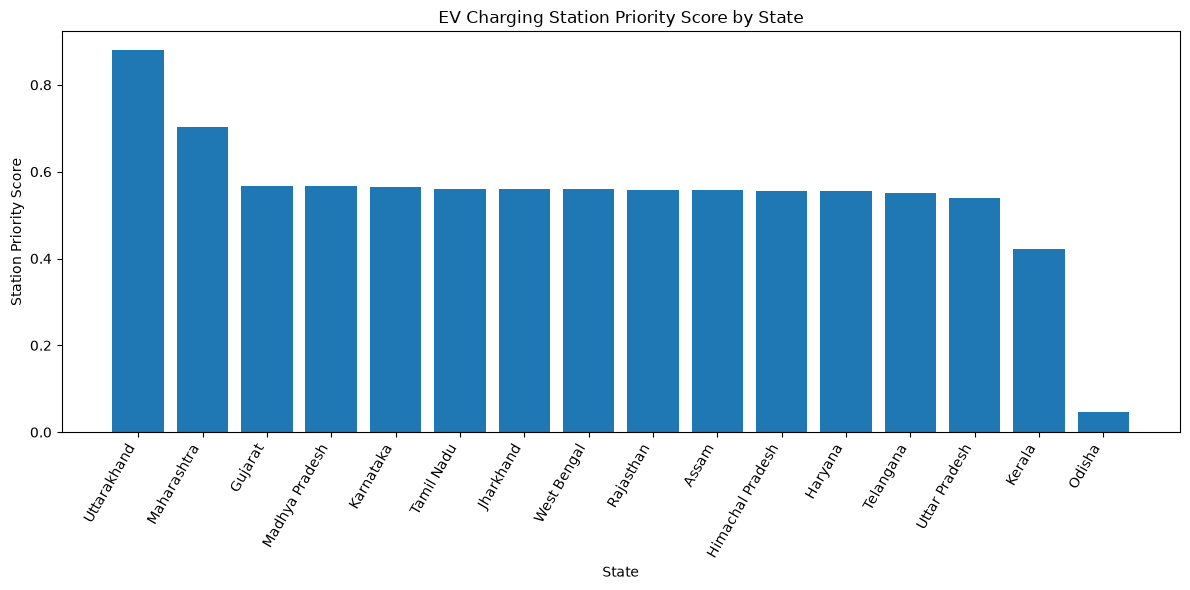

In [65]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_priority["Clean_State"],
    final_priority["Station_Priority_Score"]
)

plt.title("EV Charging Station Priority Score by State")
plt.xlabel("State")
plt.ylabel("Station Priority Score")

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [67]:
%pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.2 MB 2.3 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.2 MB 2.9 MB/s eta 0:00:03
   ----------------- ---------------------- 3.7/8.2 MB 4.0 MB/s eta 0:00:02
   -------------------------- ------------- 5.5/8.2 MB 5.0 MB/s eta 0:00:01
   ----------------------------------- ---- 7.3/8.2 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 5.6 MB/s  0:00:01
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.6 MB 4.0 MB/s eta 0:00:09
   --- ------------------------------------ 2.9/36.6 MB 6.4 MB/s eta 0:00:06
   --- ------------------------------------ 3.4/36.6 MB 5.2 MB/s eta 0:00:07
   ---- ------------------------

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Scikit-learn is working!")

Scikit-learn is working!


In [2]:
print("HELLO")

HELLO


In [5]:
import pandas as pd

ev_stations = pd.read_csv(
    r"C:\Users\mariyam\Downloads\ev_charging_stations_india_cleaned.csv"
)

print("Dataset loaded successfully!")
print(ev_stations.shape)

Dataset loaded successfully!
(1000, 10)


In [6]:
ev_stations["Operational_Flag"] = (
    ev_stations["status"]
    .astype(str)
    .str.strip()
    .eq("Operational")
    .astype(int)
)

ev_stations["Active_Charging_Points"] = (
    ev_stations["charging_points"] *
    ev_stations["Operational_Flag"]
)

print("Operational stations:", ev_stations["Operational_Flag"].sum())
print("Active charging points:", ev_stations["Active_Charging_Points"].sum())

Operational stations: 969
Active charging points: 2320


In [7]:
cluster_data = ev_stations[
    ["latitude", "longitude", "charging_points"]
].copy()

print("Cluster data shape:", cluster_data.shape)
cluster_data.head()

Cluster data shape: (1000, 3)


,latitude,longitude,charging_points
0,18.717182,74.182921,1
1,17.340476,78.545395,1
2,22.286961,86.790983,1
3,22.449744,86.594944,2
4,22.449858,86.595041,1


In [8]:
scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

print("Standardization completed!")
print("Shape:", cluster_scaled.shape)

Standardization completed!
Shape: (1000, 3)


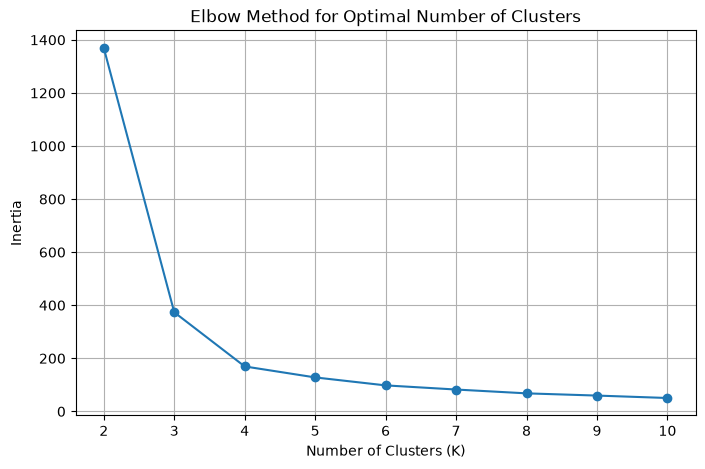

In [9]:
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

ev_stations["Cluster"] = kmeans.fit_predict(cluster_scaled)

print("K-Means clustering completed!")
print(ev_stations["Cluster"].value_counts().sort_index())

K-Means clustering completed!
Cluster
0    563
1    374
2      1
3     62
Name: count, dtype: int64


In [11]:
cluster_summary = (
    ev_stations.groupby("Cluster")
    .agg(
        Stations=("station_id", "count"),
        Avg_Charging_Points=("charging_points", "mean"),
        Total_Charging_Points=("charging_points", "sum"),
        Avg_Latitude=("latitude", "mean"),
        Avg_Longitude=("longitude", "mean"),
        Operational_Stations=("Operational_Flag", "sum")
    )
)

cluster_summary

,Stations,Avg_Charging_Points,Total_Charging_Points,Avg_Latitude,Avg_Longitude,Operational_Stations
Cluster,,,,,,
0,563,2.159858,1216,10.449591,76.414841,548
1,374,1.192513,446,20.116164,84.515096,364
2,1,600.000000,600,21.016109,81.702900,1
3,62,1.645161,102,25.605424,77.018125,56


In [12]:
cluster_2_station = ev_stations[
    ev_stations["Cluster"] == 2
][
    [
        "station_id",
        "station_name",
        "city",
        "state",
        "latitude",
        "longitude",
        "charging_points",
        "status",
        "operator"
    ]
]

cluster_2_station

,station_id,station_name,city,state,latitude,longitude,charging_points,status,operator
110,479330,Electric Vehicle Charging Station,Unknown,Odisha,21.016109,81.7029,600,Operational,Unknown


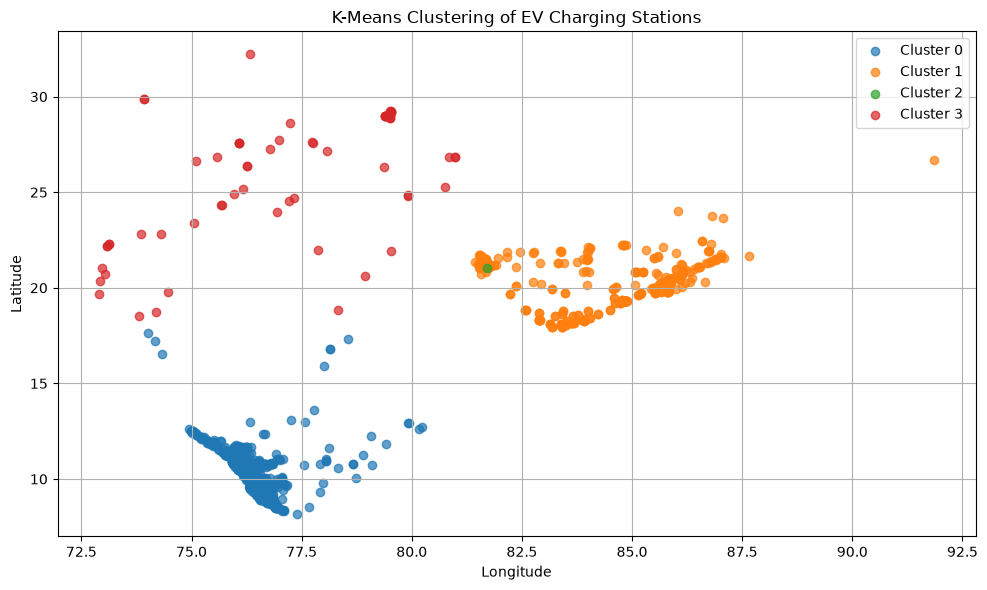

In [13]:
plt.figure(figsize=(10, 6))

for cluster in sorted(ev_stations["Cluster"].unique()):
    cluster_points = ev_stations[
        ev_stations["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_points["longitude"],
        cluster_points["latitude"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title("K-Means Clustering of EV Charging Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

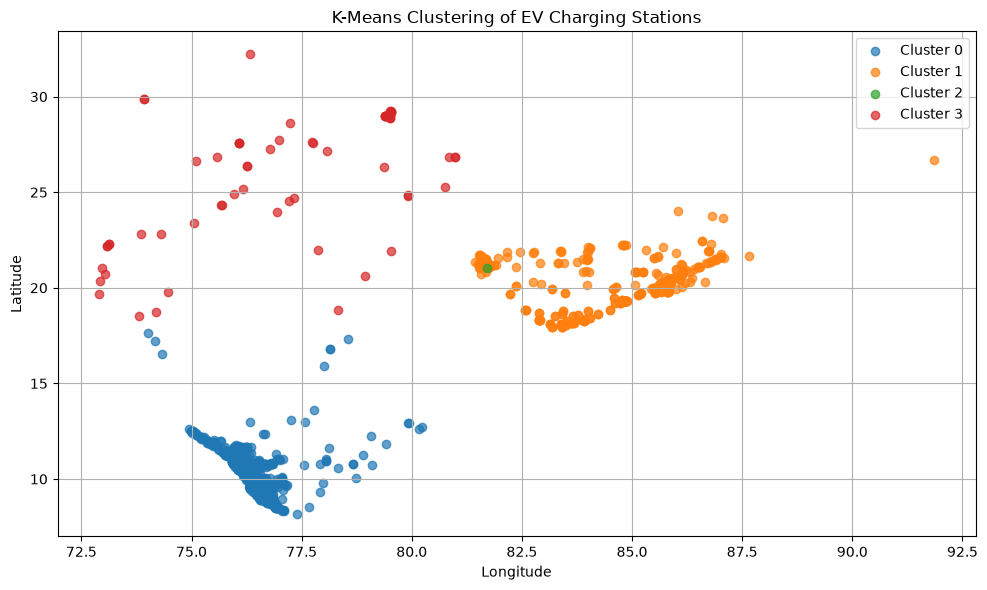

In [14]:
plt.figure(figsize=(10, 6))

for cluster in sorted(ev_stations["Cluster"].unique()):
    cluster_points = ev_stations[
        ev_stations["Cluster"] == cluster
    ]

    plt.scatter(
        cluster_points["longitude"],
        cluster_points["latitude"],
        label=f"Cluster {cluster}",
        alpha=0.7
    )

plt.title("K-Means Clustering of EV Charging Stations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
Q1 = ev_stations["charging_points"].quantile(0.25)
Q3 = ev_stations["charging_points"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower_limit)
print("Upper Limit:", upper_limit)

Q1: 1.0
Q3: 2.0
IQR: 1.0
Lower Limit: -0.5
Upper Limit: 3.5


In [16]:
ev_stations["Anomaly_Flag"] = (
    ev_stations["charging_points"] > upper_limit
)

print("Potential anomalies:", ev_stations["Anomaly_Flag"].sum())

Potential anomalies: 87


In [18]:
state_mapping = {
    "GJ": "Gujarat",
    "MH": "Maharashtra",
    "MP": "Madhya Pradesh",
    "RJ": "Rajasthan",
    "Keral": "Kerala",
    "Keraka": "Kerala",
    "Lerala": "Kerala",
    "TAMILNADU": "Tamil Nadu",
    "Uttarakhnad": "Uttarakhand",
    "UTTAR PRADESH": "Uttar Pradesh"
}

ev_stations["Clean_State"] = (
    ev_stations["state"]
    .astype(str)
    .str.strip()
    .replace(state_mapping)
    .str.title()
)

print("Clean_State recreated successfully!")

Clean_State recreated successfully!


In [19]:
anomaly_by_state = (
    ev_stations[ev_stations["Anomaly_Flag"]]
    .groupby("Clean_State")
    .agg(
        Anomaly_Stations=("station_id", "count"),
        Anomaly_Charging_Points=("charging_points", "sum")
    )
    .sort_values(
        "Anomaly_Charging_Points",
        ascending=False
    )
)

anomaly_by_state

,Anomaly_Stations,Anomaly_Charging_Points
Clean_State,,
Odisha,6,638
Kerala,73,380
Uttar Pradesh,3,17
Rajasthan,2,8
Tamil Nadu,2,8
Telangana,1,6


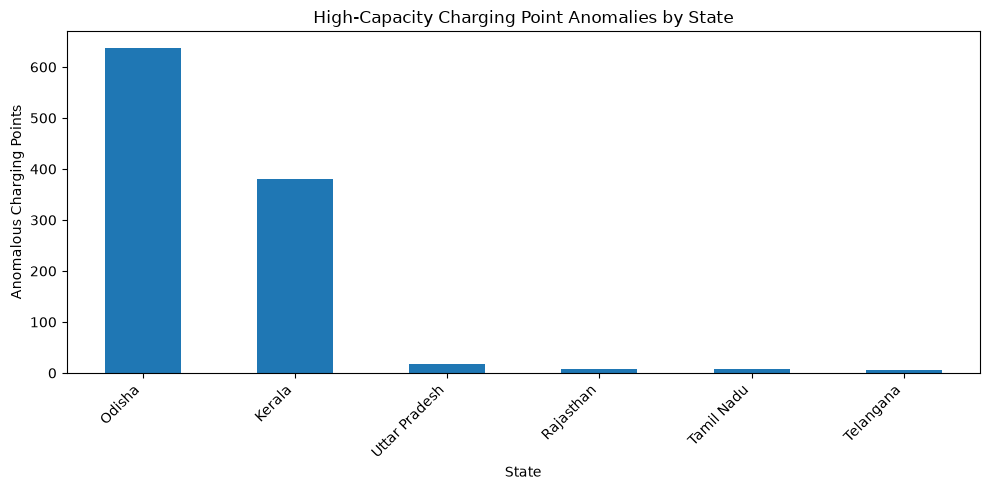

In [20]:
anomaly_by_state["Anomaly_Charging_Points"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("High-Capacity Charging Point Anomalies by State")
plt.xlabel("State")
plt.ylabel("Anomalous Charging Points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

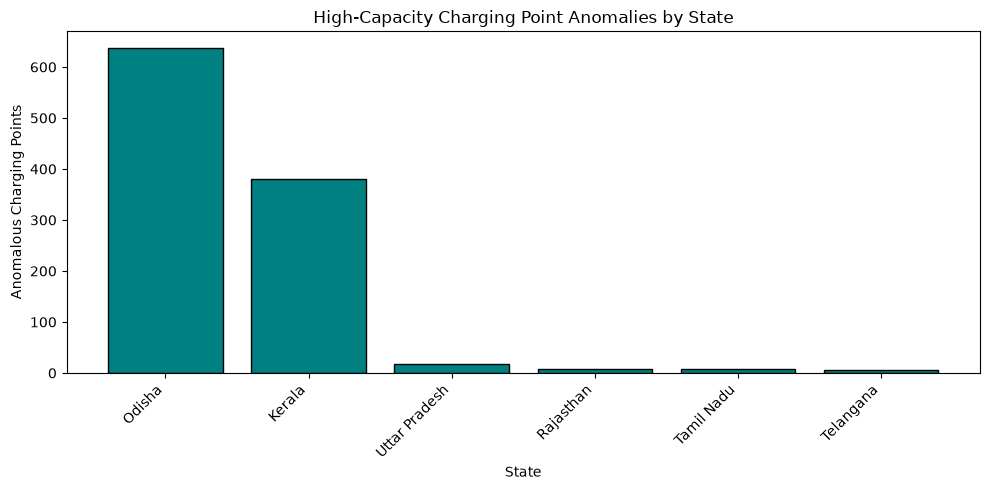

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    anomaly_by_state.index,
    anomaly_by_state["Anomaly_Charging_Points"],
    color="teal",
    edgecolor="black"
)

plt.title("High-Capacity Charging Point Anomalies by State")
plt.xlabel("State")
plt.ylabel("Anomalous Charging Points")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [23]:
top_stations = (
    ev_stations[
        [
            "station_id",
            "station_name",
            "city",
            "Clean_State",
            "charging_points",
            "status",
            "Anomaly_Flag"
        ]
    ]
    .sort_values("charging_points", ascending=False)
    .head(10)
)

top_stations

,station_id,station_name,city,Clean_State,charging_points,status,Anomaly_Flag
110,479330,Electric Vehicle Charging Station,Unknown,Odisha,600,Operational,True
294,479140,Electric Vehicle Charging Station,Unknown,Odisha,11,Operational,True
634,313915,Lulu International Mall EVCS - GO EC,Thiruvananthapuram,Kerala,11,Operational,True
210,479230,Electric Vehicle Charging Station,Unknown,Odisha,11,Operational,True
801,313702,Kulappully KSEB EVCS - ChargeMOD,Kulappully,Kerala,9,Operational,True
908,313574,Quick Charge EVCS - ChargeMOD,Karuvatta,Kerala,7,Operational,True
448,475660,Bundelkhand Expressway 188 Km Rest Area,Unknown,Uttar Pradesh,7,Operational,True
688,313861,Daffodils EVCS - GO EC,Edapally,Kerala,7,Operational,True
750,313754,Kanhangad KSEB EVCS - ChangeMOD,Kanhangad,Kerala,7,Operational,True
183,479257,Kazam Charging Station,Unknown,Odisha,7,Operational,True


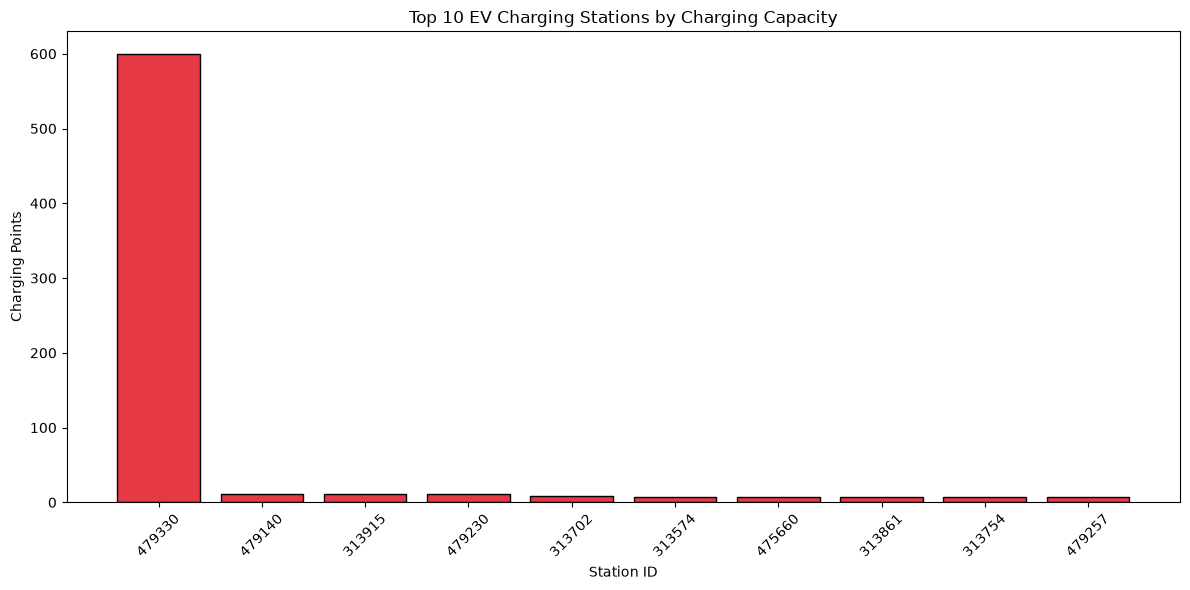

In [24]:
plt.figure(figsize=(12, 6))

plt.bar(
    top_stations["station_id"].astype(str),
    top_stations["charging_points"],
    color="#E63946",
    edgecolor="black"
)

plt.title("Top 10 EV Charging Stations by Charging Capacity")
plt.xlabel("Station ID")
plt.ylabel("Charging Points")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
state_priority = (
    ev_stations.groupby("Clean_State")
    .agg(
        Total_Stations=("station_id", "count"),
        Total_Charging_Points=("charging_points", "sum"),
        Operational_Stations=("Operational_Flag", "sum")
    )
    .reset_index()
)

state_priority["Operational_Rate"] = (
    state_priority["Operational_Stations"] /
    state_priority["Total_Stations"]
)

total_stations = state_priority["Total_Stations"].sum()
total_points = state_priority["Total_Charging_Points"].sum()

state_priority["Station_Share"] = (
    state_priority["Total_Stations"] / total_stations
)

state_priority["Charging_Point_Share"] = (
    state_priority["Total_Charging_Points"] / total_points
)

state_priority["Infrastructure_Gap"] = (
    state_priority["Station_Share"] -
    state_priority["Charging_Point_Share"]
)

print("State infrastructure gap calculated successfully!")

State infrastructure gap calculated successfully!


In [27]:
gap_analysis = state_priority[
    [
        "Clean_State",
        "Total_Stations",
        "Total_Charging_Points",
        "Station_Share",
        "Charging_Point_Share",
        "Infrastructure_Gap"
    ]
].copy()

gap_analysis = gap_analysis.sort_values(
    "Infrastructure_Gap",
    ascending=False
)

gap_analysis

,Clean_State,Total_Stations,Total_Charging_Points,Station_Share,Charging_Point_Share,Infrastructure_Gap
6,Kerala,520,1135,0.520,0.480118,0.039882
16,Uttarakhand,14,15,0.014,0.006345,0.007655
12,Tamil Nadu,27,52,0.027,0.021997,0.005003
1,Gujarat,9,12,0.009,0.005076,0.003924
7,Madhya Pradesh,9,12,0.009,0.005076,0.003924
5,Karnataka,6,7,0.006,0.002961,0.003039
8,Maharashtra,6,8,0.006,0.003384,0.002616
11,Rajasthan,12,23,0.012,0.009729,0.002271
14,Unknown,6,11,0.006,0.004653,0.001347
17,West Bengal,2,2,0.002,0.000846,0.001154


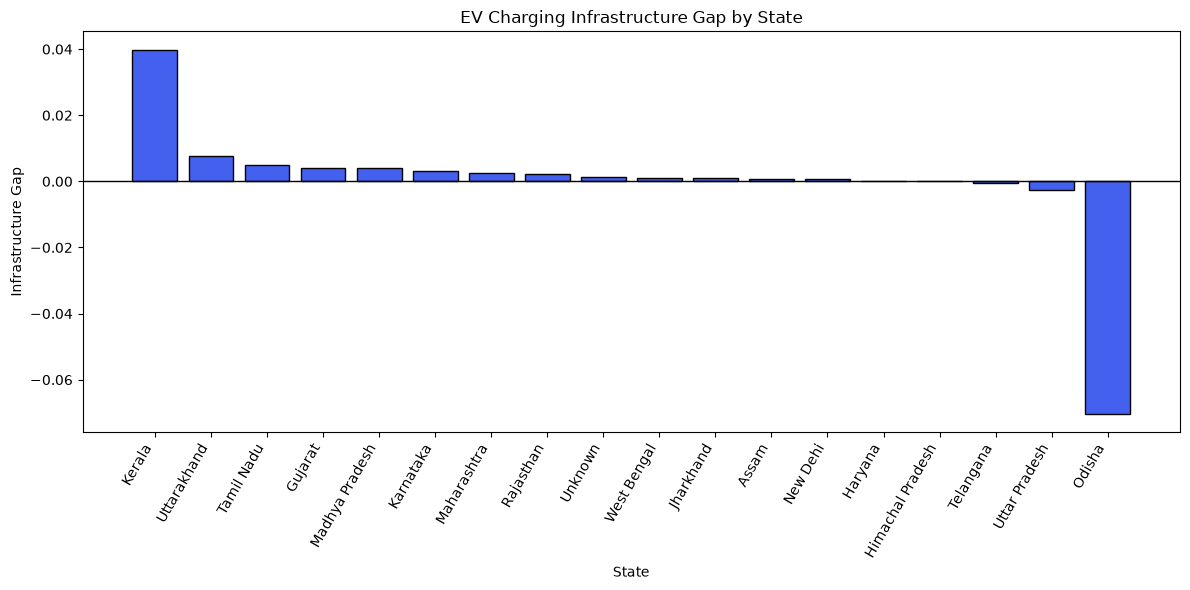

In [28]:
plt.figure(figsize=(12, 6))

plt.bar(
    gap_analysis["Clean_State"],
    gap_analysis["Infrastructure_Gap"],
    color="#4361EE",
    edgecolor="black"
)

plt.axhline(0, color="black", linewidth=1)

plt.title("EV Charging Infrastructure Gap by State")
plt.xlabel("State")
plt.ylabel("Infrastructure Gap")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd

ev_sales = pd.read_csv(
    r"C:\Users\mariyam\Downloads\Indian_EV_Sales_2015_2025.csv"
)

print(ev_sales.shape)
print(ev_sales.columns.tolist())

(19, 6)
['Year', 'State/UT', 'Vehicle_Category', 'Segment', 'Sales_Quantity', 'EV_Penetration (%)']


In [32]:
two_wheeler_sales = ev_sales[
    ev_sales["Segment"] == "High-speed e2W"
].sort_values("Year")

two_wheeler_sales

,Year,State/UT,Vehicle_Category,Segment,Sales_Quantity,EV_Penetration (%)
0,2015,India,Two-Wheeler,High-speed e2W,15000,0.1
1,2016,India,Two-Wheeler,High-speed e2W,22000,0.2
2,2017,India,Two-Wheeler,High-speed e2W,34000,0.3
3,2018,India,Two-Wheeler,High-speed e2W,56000,0.5
4,2019,India,Two-Wheeler,High-speed e2W,152000,1.1
5,2020,India,Two-Wheeler,High-speed e2W,240000,1.8
6,2021,India,Two-Wheeler,High-speed e2W,415000,2.3
7,2022,India,Two-Wheeler,High-speed e2W,629000,3.6
8,2023,India,Two-Wheeler,High-speed e2W,873000,5.1
9,2024,India,Two-Wheeler,High-speed e2W,1211193,6.2


In [33]:
sales_start = two_wheeler_sales["Sales_Quantity"].iloc[0]
sales_end = two_wheeler_sales["Sales_Quantity"].iloc[-1]

sales_growth_percent = (
    (sales_end - sales_start) / sales_start
) * 100

print("Starting EV Sales:", sales_start)
print("Ending EV Sales:", sales_end)
print("EV Sales Growth:", round(sales_growth_percent, 2), "%")

Starting EV Sales: 15000
Ending EV Sales: 1390000
EV Sales Growth: 9166.67 %


In [34]:
state_priority["Infrastructure_Availability_Gap"] = (
    1 - state_priority["Charging_Point_Share"]
)

state_priority["Operational_Gap"] = (
    1 - state_priority["Operational_Rate"]
)

print("Required scorecard variables created!")

Required scorecard variables created!


In [35]:
# Normalize Infrastructure Gap
state_priority["Infrastructure_Gap_Norm"] = (
    (state_priority["Infrastructure_Gap"] -
     state_priority["Infrastructure_Gap"].min())
    /
    (state_priority["Infrastructure_Gap"].max() -
     state_priority["Infrastructure_Gap"].min())
)

# Normalize Operational Gap
state_priority["Operational_Gap_Norm"] = (
    (state_priority["Operational_Gap"] -
     state_priority["Operational_Gap"].min())
    /
    (state_priority["Operational_Gap"].max() -
     state_priority["Operational_Gap"].min())
)

# Normalize Charging Point Availability
state_priority["Charging_Points_Norm"] = (
    (state_priority["Total_Charging_Points"] -
     state_priority["Total_Charging_Points"].min())
    /
    (state_priority["Total_Charging_Points"].max() -
     state_priority["Total_Charging_Points"].min())
)

state_priority["Infrastructure_Availability_Gap"] = (
    1 - state_priority["Charging_Points_Norm"]
)

print("Normalization completed successfully!")

Normalization completed successfully!


In [36]:
state_priority["Station_Priority_Score"] = (
    0.40 * state_priority["Infrastructure_Gap_Norm"]
    + 0.30 * state_priority["Operational_Gap_Norm"]
    + 0.30 * state_priority["Infrastructure_Availability_Gap"]
)

print("Final Station Priority Score calculated successfully!")

Final Station Priority Score calculated successfully!


In [37]:
final_scorecard = state_priority[
    [
        "Clean_State",
        "Total_Stations",
        "Total_Charging_Points",
        "Operational_Rate",
        "Infrastructure_Gap",
        "Station_Priority_Score"
    ]
].copy()

final_scorecard = final_scorecard.sort_values(
    "Station_Priority_Score",
    ascending=False
)

final_scorecard

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Rate,Infrastructure_Gap,Station_Priority_Score
16,Uttarakhand,14,15,0.642857,0.007655,0.879360
8,Maharashtra,6,8,0.833333,0.002616,0.702928
14,Unknown,6,11,0.833333,0.001347,0.697529
1,Gujarat,9,12,1.000000,0.003924,0.566616
7,Madhya Pradesh,9,12,1.000000,0.003924,0.566616
5,Karnataka,6,7,1.000000,0.003039,0.564727
12,Tamil Nadu,27,52,1.000000,0.005003,0.559951
17,West Bengal,2,2,1.000000,0.001154,0.559211
4,Jharkhand,2,2,1.000000,0.001154,0.559211
11,Rajasthan,12,23,1.000000,0.002271,0.557707


In [38]:
final_scorecard_clean = final_scorecard[
    ~final_scorecard["Clean_State"].isin(["Unknown", "New Dehi"])
].copy()

final_scorecard_clean

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Rate,Infrastructure_Gap,Station_Priority_Score
16,Uttarakhand,14,15,0.642857,0.007655,0.879360
8,Maharashtra,6,8,0.833333,0.002616,0.702928
1,Gujarat,9,12,1.000000,0.003924,0.566616
7,Madhya Pradesh,9,12,1.000000,0.003924,0.566616
5,Karnataka,6,7,1.000000,0.003039,0.564727
12,Tamil Nadu,27,52,1.000000,0.005003,0.559951
17,West Bengal,2,2,1.000000,0.001154,0.559211
4,Jharkhand,2,2,1.000000,0.001154,0.559211
11,Rajasthan,12,23,1.000000,0.002271,0.557707
0,Assam,1,1,1.000000,0.000577,0.557381


In [39]:
final_scorecard_clean = final_scorecard[
    ~final_scorecard["Clean_State"].isin(["Unknown", "New Dehi"])
].copy()

final_scorecard_clean

,Clean_State,Total_Stations,Total_Charging_Points,Operational_Rate,Infrastructure_Gap,Station_Priority_Score
16,Uttarakhand,14,15,0.642857,0.007655,0.879360
8,Maharashtra,6,8,0.833333,0.002616,0.702928
1,Gujarat,9,12,1.000000,0.003924,0.566616
7,Madhya Pradesh,9,12,1.000000,0.003924,0.566616
5,Karnataka,6,7,1.000000,0.003039,0.564727
12,Tamil Nadu,27,52,1.000000,0.005003,0.559951
17,West Bengal,2,2,1.000000,0.001154,0.559211
4,Jharkhand,2,2,1.000000,0.001154,0.559211
11,Rajasthan,12,23,1.000000,0.002271,0.557707
0,Assam,1,1,1.000000,0.000577,0.557381


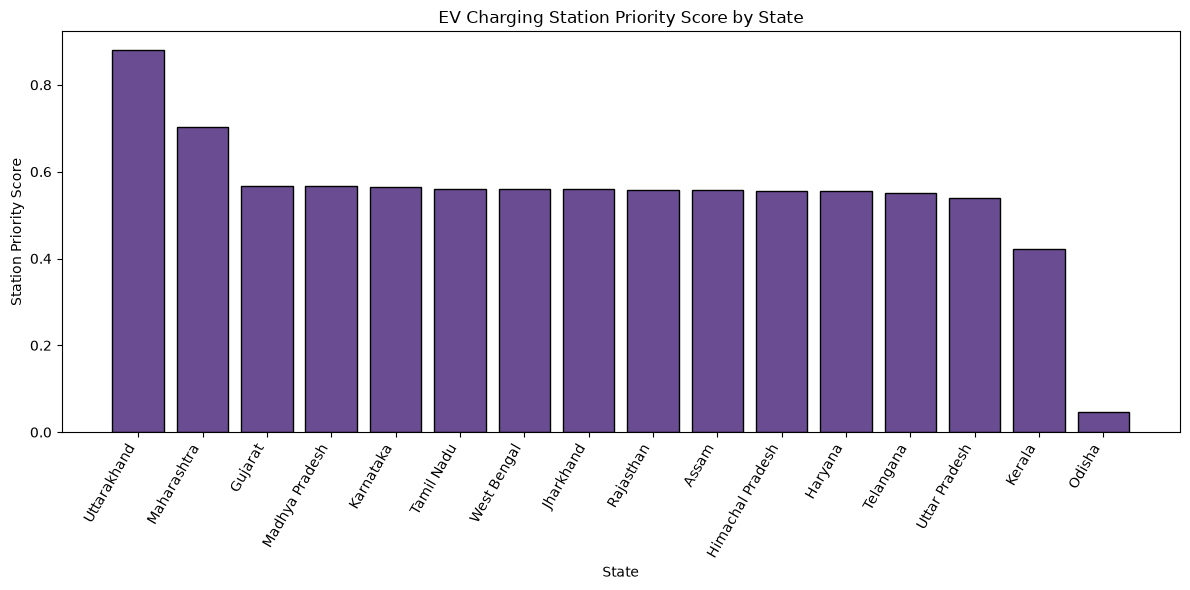

In [40]:
plt.figure(figsize=(12, 6))

plt.bar(
    final_scorecard_clean["Clean_State"],
    final_scorecard_clean["Station_Priority_Score"],
    color="#6A4C93",
    edgecolor="black"
)

plt.title("EV Charging Station Priority Score by State")
plt.xlabel("State")
plt.ylabel("Station Priority Score")
plt.xticks(rotation=60, ha="right")

plt.tight_layout()
plt.show()

In [41]:
import os

powerbi_folder = r"C:\Users\mariyam\Desktop\EV_ChargeMap_Intelligence\4_PowerBI"

os.makedirs(powerbi_folder, exist_ok=True)

ev_stations.to_csv(
    os.path.join(powerbi_folder, "EV_Charging_Stations_Analysis.csv"),
    index=False
)

final_scorecard_clean.to_csv(
    os.path.join(powerbi_folder, "State_Priority_Scorecard.csv"),
    index=False
)

print("Power BI files exported successfully!")

Power BI files exported successfully!
